Policy Iteration with different state-loop orders (evaluation step)
Forward order: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Reverse order: [10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
Random order (seed=42): [6, 7, 0, 10, 3, 5, 2, 4, 9, 1, 8]

Policy-improvement rounds (forward): 6
Policy-improvement rounds (reverse): 6
Policy-improvement rounds (random): 6
Total evaluation iterations (forward): 285
Total evaluation iterations (reverse): 285
Total evaluation iterations (random): 285
Same optimal values? forward vs reverse: True
Same optimal values? forward vs random: True
Same optimal policy? forward vs reverse: True
Same optimal policy? forward vs random: True

Final sum of values (forward): 62.000000
Final sum of values (reverse): 62.000000
Final sum of values (random): 62.000000
s=0: ['U', 'R']
s=1: ['U']
s=2: ['R']
s=3: ['R']
s=4: ['R']
s=5: ['U']
s=6: ['U']
s=7: ['R']
s=8: ['L']
s=9: ['U', 'D', 'L', 'R']
s=10: ['U', 'D', 'L', 'R']


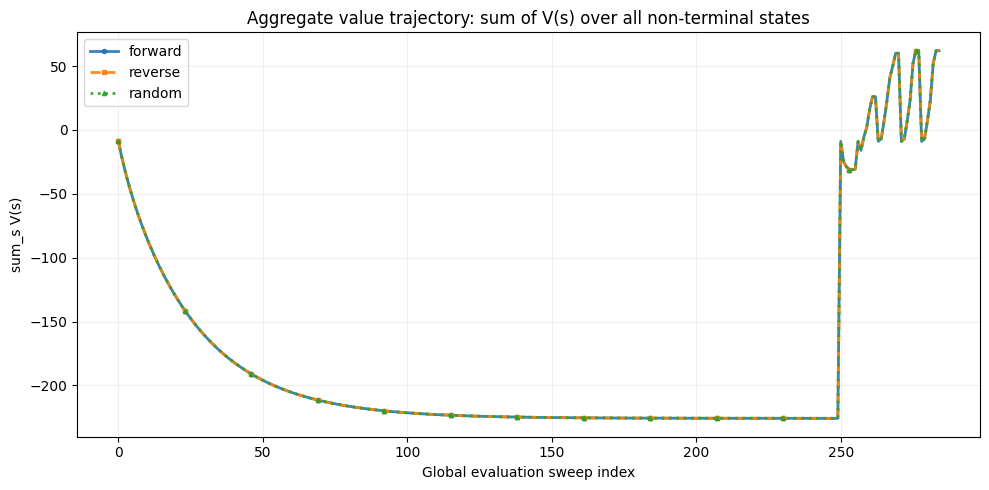

In [7]:
import numpy as np
import matplotlib.pyplot as plt

states = list(range(11)) + ["T"]
nonterminal = list(range(11))
terminal = "T"
gamma = 1.0

# Action indices: 0=U, 1=D, 2=L, 3=R
action_names = ["U", "D", "L", "R"]

# Hard-coded transitions for this specific grid (U, D, L, R)
next_states = {
    0: [1, 0, 0, 3],
    1: [2, 0, 1, 1],
    2: [2, 1, 2, 4],
    3: [3, 3, 0, 5],
    4: [4, 4, 2, 7],
    5: [6, 5, 3, 8],
    6: [7, 5, 6, 9],
    7: [7, 6, 4, 10],
    8: [9, 8, 5, 8],
    9: [terminal, terminal, terminal, terminal],   # trap -> terminal
    10: [terminal, terminal, terminal, terminal],  # goal -> terminal
}

# Rewards for U, D, L, R
rewards = {s: [-1.0, -1.0, -1.0, -1.0] for s in range(9)}
rewards[9] = [-10.0, -10.0, -10.0, -10.0]
rewards[10] = [10.0, 10.0, 10.0, 10.0]

theta = 1e-4
max_eval_iter = 100000
max_outer = 1000

rng = np.random.default_rng(42)
random_order = rng.permutation(nonterminal).tolist()

order_map = {
    "forward": list(range(11)),
    "reverse": list(reversed(range(11))),
    "random": random_order,
}

results = {}
for run_name, order in order_map.items():
    # Start from random policy
    policy = {s: [0.25, 0.25, 0.25, 0.25] for s in nonterminal}
    total_eval_iters = 0

    value_sum_trace = []

    for outer in range(max_outer):
        # ---------- Policy Evaluation ----------
        V = {s: 0.0 for s in states}
        V[terminal] = 0.0

        eval_iters = 0
        for it in range(max_eval_iter):
            delta = 0.0
            V_new = V.copy()

            for s in order:
                val = 0.0
                for a in range(4):
                    pi_sa = policy[s][a]
                    s_next = next_states[s][a]
                    r = rewards[s][a]
                    val += pi_sa * (r + gamma * V[s_next])
                V_new[s] = val
                delta = max(delta, abs(V_new[s] - V[s]))

            V = V_new
            eval_iters = it + 1
            value_sum_trace.append(sum(V[s] for s in nonterminal))

            if delta < theta:
                break

        total_eval_iters += eval_iters

        # ---------- Policy Improvement ----------
        new_policy = {}
        for s in nonterminal:
            q = []
            for a in range(4):
                s_next = next_states[s][a]
                r = rewards[s][a]
                q.append(r + gamma * V[s_next])

            best = max(q)
            best_actions = [a for a, val in enumerate(q) if abs(val - best) < 1e-12]

            probs = [0.0, 0.0, 0.0, 0.0]
            for a in best_actions:
                probs[a] = 1.0 / len(best_actions)
            new_policy[s] = probs

        stable = True
        for s in nonterminal:
            if any(abs(new_policy[s][a] - policy[s][a]) > 1e-12 for a in range(4)):
                stable = False
                break

        policy = new_policy
        if stable:
            policy_rounds = outer + 1
            break
    else:
        policy_rounds = max_outer

    results[run_name] = {
        "order": order,
        "V": V,
        "policy": policy,
        "policy_rounds": policy_rounds,
        "eval_iters": total_eval_iters,
        "value_sum_trace": value_sum_trace,
    }

V_fwd = results["forward"]["V"]
V_rev = results["reverse"]["V"]
V_rand = results["random"]["V"]

pi_fwd = results["forward"]["policy"]
pi_rev = results["reverse"]["policy"]
pi_rand = results["random"]["policy"]

policy_rounds_fwd = results["forward"]["policy_rounds"]
policy_rounds_rev = results["reverse"]["policy_rounds"]
policy_rounds_rand = results["random"]["policy_rounds"]

eval_iters_fwd = results["forward"]["eval_iters"]
eval_iters_rev = results["reverse"]["eval_iters"]
eval_iters_rand = results["random"]["eval_iters"]

same_values_fwd_rev = max(abs(V_fwd[s] - V_rev[s]) for s in nonterminal) < 1e-10
same_values_fwd_rand = max(abs(V_fwd[s] - V_rand[s]) for s in nonterminal) < 1e-10

same_policy_fwd_rev = all(
    all(abs(pi_fwd[s][a] - pi_rev[s][a]) < 1e-12 for a in range(4))
    for s in nonterminal
)
same_policy_fwd_rand = all(
    all(abs(pi_fwd[s][a] - pi_rand[s][a]) < 1e-12 for a in range(4))
    for s in nonterminal
)

print("Policy Iteration with different state-loop orders (evaluation step)")
print(f"Forward order: {order_map['forward']}")
print(f"Reverse order: {order_map['reverse']}")
print(f"Random order (seed=42): {order_map['random']}")
print()
print(f"Policy-improvement rounds (forward): {policy_rounds_fwd}")
print(f"Policy-improvement rounds (reverse): {policy_rounds_rev}")
print(f"Policy-improvement rounds (random): {policy_rounds_rand}")
print(f"Total evaluation iterations (forward): {eval_iters_fwd}")
print(f"Total evaluation iterations (reverse): {eval_iters_rev}")
print(f"Total evaluation iterations (random): {eval_iters_rand}")
print(f"Same optimal values? forward vs reverse: {same_values_fwd_rev}")
print(f"Same optimal values? forward vs random: {same_values_fwd_rand}")
print(f"Same optimal policy? forward vs reverse: {same_policy_fwd_rev}")
print(f"Same optimal policy? forward vs random: {same_policy_fwd_rand}")
print()
print(f"Final sum of values (forward): {sum(V_fwd[s] for s in nonterminal):.6f}")
print(f"Final sum of values (reverse): {sum(V_rev[s] for s in nonterminal):.6f}")
print(f"Final sum of values (random): {sum(V_rand[s] for s in nonterminal):.6f}")

# Optional compact policy display
for s in nonterminal:
    chosen = [action_names[a] for a in range(4) if pi_fwd[s][a] > 0]
    print(f"s={s}: {chosen}")

# ---------- Aggregate convergence plot ----------
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

style_map = {"forward": "-", "reverse": "--", "random": ":"}
marker_map = {"forward": "o", "reverse": "s", "random": "^"}

for run_name in ["forward", "reverse", "random"]:
    trace = results[run_name]["value_sum_trace"]
    mark_every = max(1, len(trace) // 12)
    ax.plot(
        trace,
        label=run_name,
        linestyle=style_map[run_name],
        marker=marker_map[run_name],
        markevery=mark_every,
        linewidth=2.0,
        markersize=3,
        alpha=0.9,
    )

ax.set_title("Aggregate value trajectory: sum of V(s) over all non-terminal states")
ax.set_xlabel("Global evaluation sweep index")
ax.set_ylabel("sum_s V(s)")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()